In [86]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple

# Can use either of these two as ground truth
# ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
# ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))


Nms = 60
file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
infinite_iterations = 200 # should be 200
_fname = os.path.join(data_path, 'recons_ignore-acq_4bis', f'MS_{Nms}', file_pattern.format('PDHG', Nms, infinite_iterations) )
ground_truth_with_TV = pMR.ImageData(file=_fname).as_array()


def rmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse)

def nrmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse) / np.max(np.abs(ground_truth))

def ssim(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    res_ssim = structural_similarity(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return res_ssim


def read_data(data_path, algo, Nms, ground_truth):
    recons_dir = 'recons_ignore-acq_4bis'
    if algo not in ['FISTA', 'PDHG', 'SPDHG']:
        raise ValueError('algo must be one of FISTA, PDHG, SPDHG')
    res = {'rmse': [], 'nrmse': [], 'ssim': []}
    file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
    itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj = np.load(itrobj_fname)
    res['iterations'] = itrobj[0].astype(int)
    res['objective'] = itrobj[1]
    itr = itrobj[0][1:].astype(int)

    for it in itr:
        _fname = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it) )
        if os.path.exists(_fname):
            res['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
            res['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
            # res['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth) )

    return res

In [87]:
all_res_pdhg = read_data(data_path, 'PDHG', Nms, ground_truth_with_TV)
res_spdhg = read_data(data_path, 'SPDHG', Nms, ground_truth_with_TV)
# res_fista = read_data(data_path, 'FISTA', Nms, ground_truth_with_TV)

r of images: 1
image data type: 7
variable xml
group 2024-04-26 01:40:02
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 01:53:38
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 01:53:38
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:07:13
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:07:13
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:20:40
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:20:40
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:34:06
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:34:06
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-26 02:47:31
variable image_0
number of images: 1
image data type: 7
variable xml
gro

In [88]:
# remove the iterations larger than 100 from PDHG
resmaxiter = 100
filt = all_res_pdhg['iterations'] <= resmaxiter
print (filt)
res_pdhg = {}
for k,v in all_res_pdhg.items():
    print (k,v)
    offset = 1
    if k in ['iterations', 'objective']:
        offset = 0
    if len(v) > 0:
        res_pdhg[k] = np.asarray(v)[filt[offset:]]
print (res_pdhg)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False False False False False False False False False False]
rmse [8.05464679886935e-06, 6.643372989454266e-06, 5.257658675753523e-06, 4.087302564083524e-06, 3.0933506091698494e-06, 2.4214062339110376e-06, 2.189899129192373e-06, 2.3503778756655225e-06, 2.6017936131837043e-06, 2.743024873974925e-06, 2.722290846862478e-06, 2.5701650232949706e-06, 2.346442034557817e-06, 2.1100127295436203e-06, 1.914704816859335e-06, 1.536042469182725e-06, 9.491364707061505e-07, 5.760626023205415e-07, 4.080373202134264e-07, 2.8613846788535763e-07, 2.0324849544887737e-07, 1.4094881624683524e-07, 9.600818539566782e-08, 7.06829424641313e-08, 5.266667103827372e-08, 4.080111601385912e-08, 3.190785665790465e-08, 2.440709561999629e-08, 1.8734937336489217e-08, 1.431775313053902e-08, 1.0635611691625521e-08, 7.0389297264654064e-09, 3.388123715923006e-09, 0.0]
nrmse 

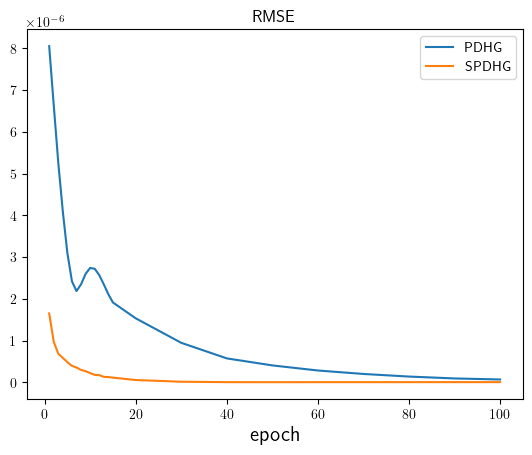

In [89]:
# epochs = [it * 10 for it in range(1,11)]
plt.plot(res_pdhg['iterations'][1:], res_pdhg['rmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['rmse'], label='SPDHG' )
# plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot(epochs_spdhg, res_spdhg_all['rmse'], label='SPDHG' )
plt.legend()
plt.title('RMSE')
plt.xlabel('epoch')
plt.show()

In [ ]:
# Determine iteration where the difference is below convergence_threshold
def find_epoch_below_threshold(results, reference_rmse, threshold):
    rmse = results['rmse'] / reference_rmse
    iterations = results['iterations'][1:]
    for i,r in enumerate(rmse):
        if r < threshold:
            return iterations[i]
    return -1

# This is done on RMSE scaled by the np.sqrt(np.mean(reference_recon**2))

reference_rmse = np.sqrt(np.mean(ground_truth_with_TV**2))
convergence_threshold = 0.05

t_pdhg = find_epoch_below_threshold(res_pdhg, reference_rmse, convergence_threshold)
t_spdhg = find_epoch_below_threshold(res_spdhg, reference_rmse, convergence_threshold) / Nms

print(t_spdhg, t_pdhg)

/opt/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


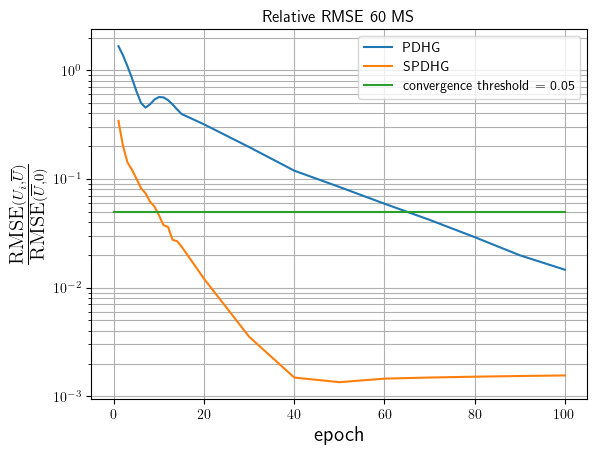

In [101]:
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.labelsize'] = 15

plt.plot(res_pdhg['iterations'][1:], res_pdhg['rmse']/reference_rmse, label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['rmse']/reference_rmse, label='SPDHG' )
# plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot(epochs_spdhg, res_spdhg_all['rmse'], label='SPDHG' )
plt.plot([0,100], [convergence_threshold]*2, '-', label=f'convergence threshold = {convergence_threshold}')
# plt.plot([t_pdhg, t_pdhg], [1e-3, convergence_threshold], '-', color='C0')
# plt.plot([t_spdhg, t_spdhg], [1e-3, convergence_threshold], '-', color='C1')
plt.legend()
plt.title(f'Relative RMSE {Nms} MS')
plt.xlabel('epoch')
plt.yscale('log')
plt.ylabel(r'$\frac{\textrm{RMSE}(U_i, \overline{U})}{\textrm{RMSE}(\overline{U},0)}$')
plt.grid(axis='both', which='both')
plt.savefig('relative_rmse.png')
plt.show()

In [91]:
def compute_delta_rmse(data_path, algo, Nms):
    recons_dir = 'recons_ignore-acq_4bis'
    if algo not in ['FISTA', 'PDHG', 'SPDHG']:
        raise ValueError('algo must be one of FISTA, PDHG, SPDHG')
    res = {'iterations': [], 'rmse': []}
    file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
    itrobj_fname = os.path.join(data_path, recons_dir, f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj = np.load(itrobj_fname)

    # relevant iterations are from iteration 1
    res['objective'] = itrobj[1]
    itr = itrobj[0][1:].astype(int)
    

    for i in range(2,len(itr)):
        it = itr[i]
        it_prev = itr[i-1]
        _fname = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it) )
        _fname_prev = os.path.join(data_path, recons_dir, f'MS_{Nms}', file_pattern.format(algo, Nms, it_prev) )
        #TODO normalise by RMSE of previous iterate
        if os.path.exists(_fname):
            prev_solution = pMR.ImageData(file=_fname_prev).as_array()
            prev_solution_rmse = np.sqrt(np.mean(ground_truth_with_TV**2))
            res['rmse'].append( 
                rmse( pMR.ImageData(file=_fname).as_array(), 
                      prev_solution) / prev_solution_rmse
            )
            res['iterations'].append(it)
            
    return res

drmse_pdhg = compute_delta_rmse(data_path, 'PDHG', Nms)
drmse_spdhg = compute_delta_rmse(data_path, 'SPDHG', Nms)


variable xml
group 2024-04-22 07:05:15
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 07:05:15
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 09:58:10
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 09:58:10
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 12:50:15
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 12:50:15
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 15:42:05
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 15:42:05
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 18:34:20
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 18:34:20
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 21:25:19
variable i

In [92]:
print (drmse_spdhg)

{'iterations': [180, 240, 300, 360, 420, 480, 540, 600, 660, 720, 780, 840, 900, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000], 'rmse': [(0.17450533975239169-0.015837440829318063j), (0.10634797383659537-0.009651737564849276j), (0.11317201616832114-0.010271061688677339j), (0.09111209217836504-0.008268986901820307j), (0.06548414865996176-0.0059430922350684j), (0.06018658271102054-0.005462305301128077j), (0.05731575913520266-0.005201760273807194j), (0.04878612847032971-0.004427643440806324j), (0.03793462877082255-0.003442802606456142j), (0.03241568686537801-0.0029419244328028693j), (0.03159045569022604-0.0028670295904701213j), (0.026778619599095943-0.002430325650740933j), (0.02622128120755093-0.0023797437384021707j), (0.026141002559261575-0.002372457953658023j), (0.012750927013067933-0.0011572256320348442j), (0.00370747964635165-0.00033647674969894756j), (0.0008043394275473803-7.299878679096183e-05j), (0.00032949387530835166-2.9903610750382222e-05j), (0.00013517220265536224-1.2267

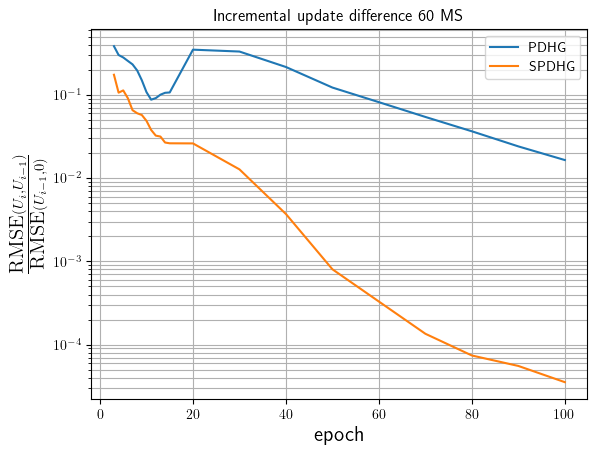

In [95]:
# import matplotlib.pylab as pylab
# params = {'axes.titlesize':'30', 'axes.labelsize':'15'}
# pylab.rcParams.update(params)
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.labelsize'] = 15

# TODO add grid lines on the plot
# green threshold dotted

# incr_threshold = 6.5e-2
incr_threshold = convergence_threshold
min_line = 1e-4

drmse_pdhg['iterations'] = np.asarray(drmse_pdhg['iterations'])
first_100 = drmse_pdhg['iterations']<101
drmse_pdhg['rmse'] = np.asarray(drmse_pdhg['rmse'])

plt.plot(drmse_pdhg['iterations'][first_100], drmse_pdhg['rmse'][first_100], '-', label='PDHG' )
plt.plot([el / Nms for el in drmse_spdhg['iterations']], drmse_spdhg['rmse'], '-', label='SPDHG' )
# plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot([0,100], [incr_threshold]*2, '-', label=f'incr convergence threshold = {incr_threshold}')
# plt.plot([0,100], [0.02]*2, '-', label=f'incr convergence threshold = {0.02}')
# plt.plot([t_pdhg, t_pdhg], [min_line, incr_threshold], '-', color='C0')
# plt.plot([t_spdhg, t_spdhg], [min_line, incr_threshold], '-', color='C1')
plt.legend()
plt.title(f'Incremental update difference {Nms} MS')
plt.xlabel('epoch')
plt.yscale('log')
plt.ylabel(r'$\frac{\textrm{RMSE}(U_i, U_{i-1})}{\textrm{RMSE}(U_{i-1},0)}$')
plt.grid(visible=True, axis='both', which='both')
plt.savefig('incremental_difference.png')
plt.show()

In [ ]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['nrmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['nrmse'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['nrmse'], label='FISTA' )
plt.legend()
plt.title('NRMSE')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['ssim'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['ssim'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['ssim'], label='FISTA' )
plt.legend()
plt.title('SSIM')
plt.xlabel('epoch')
plt.show()

In [ ]:

offset = 1
scale = 'linear'
plt.plot(res_pdhg['iterations'][offset:], res_pdhg['objective'][offset:], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][offset:]], res_spdhg['objective'][offset:], label='SPDHG' )
plt.plot(res_fista['iterations'][offset:], res_fista['objective'][offset:], label='FISTA' )
plt.xscale(scale)
plt.title(f'objective, {Nms} MS')
plt.xlabel('epoch')
plt.legend()
plt.show()



In [ ]:
num_epochs = 20
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','SPDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, Nms * num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'SPDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'SPDHG, {Nms}ms.png')

In [ ]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','PDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() -ground_truth_with_TV],
            [59, 64]*2,
            [f'PDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'PDHG, {Nms}ms.png')

In [ ]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','FISTA_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'FISTA, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'FISTA, {Nms}ms.png')

In [ ]:
plot_rpe_3d([ground_truth_with_TV],
            [59, 64],
            [f'Ground Truth: TV-PDHG, no motion'],
            [3*10**(-5)],
            f'Ground-Truth PDHG, {Nms}ms.png')

In [102]:
# Comparison wrt Nms
num_ms = [6, 30, 60]

results = {}
for algo in ['PDHG', 'SPDHG', 'FISTA']:
    results[algo] = {}

for num in num_ms:
    for algo in ['PDHG', 'SPDHG', 'FISTA']:
        results[algo][str(num)] = read_data(data_path, algo, num, ground_truth_with_TV)
        


24-04-21 21:59:53
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 22:28:10
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 22:28:10
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 22:56:02
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 22:56:02
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 23:24:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 23:24:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 23:52:58
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-21 23:52:58
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 00:21:19
variable image_0
number of images: 1
image data type: 7
variable xml
group 2024-04-22 00:21:19
variable image_0
number of image

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/SIRF-Contribs/src/notebooks/recons_ignore-acq_4bis/MS_60/FISTA_itrobj.npy'

In [ ]:
offset = 1
scale = 'log'
linestyle = ['-', '--', '-.']
linecolor = ['C0', 'C1', 'C2']

for i,algo in enumerate(['PDHG', 'SPDHG', 'FISTA']):
    for j,num in enumerate(num_ms):
        epochs = results[algo][str(num)]['iterations']
        if algo == 'SPDHG':
            epochs = [el / num for el in epochs]
        objective = results[algo][str(num)]['objective']
        plt.plot(epochs[offset:], objective[offset:]/objective[0], label=f'{algo} {num}ms' , linestyle=linestyle[j], color=linecolor[i])
plt.xscale(scale)
plt.yscale(scale)
plt.title(f'Objective for different Nms')
plt.xlabel('epochs')
plt.ylabel('Relative objective value')
plt.legend()
plt.show()
